In [1]:
# ============================================
# Lab 5: Data Visualization using Seaborn
# Student: Maryam Almutairi
# Course: CSC 230 Programming with Python
# Spring 2026
# ============================================


In [3]:
# ============================================
# TASK 1: Import Libraries and Load Dataset (1 point)
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Load the Titanic Dataset
print("="*70)
print("CSC 230 - Lab 5: Data Visualization using Seaborn")
print("Student: Maryam Almutairi")
print("="*70)

# Load dataset from CSV file
df = pd.read_csv('Titanic-Dataset.csv')
print("\n✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Display first few rows
print("\n📋 First 5 rows of the dataset:")
print("-"*50)
print(df.head())



CSC 230 - Lab 5: Data Visualization using Seaborn
Student: Maryam Almutairi

✅ Dataset loaded successfully!
📊 Dataset shape: 891 rows × 12 columns

📋 First 5 rows of the dataset:
--------------------------------------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500  

In [4]:
print("\n" + "="*70)
print("TASK 2: Data Description (1 point)")
print("="*70)

# ============================================
# TASK 2: Data Description (1 point)
# ============================================

# Display column names
print("\n📋 Column Names in the Dataset:")
print("-"*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

# Show dataset information
print("\n📊 Dataset Information:")
print("-"*50)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData Types:")
print(df.dtypes)

# Find basic statistics
print("\n📈 Basic Statistics of Numerical Columns:")
print("-"*50)
print(df.describe())

# Check for missing values
print("\n🔍 Missing Values in Each Column:")
print("-"*50)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percent})
print(missing_table[missing_table['Missing Count'] > 0] if any(missing_values > 0) else "No missing values found!")

# Display unique values for categorical columns
print("\n🏷️ Unique Values in Categorical Columns:")
print("-"*50)
categorical_cols = ['Sex', 'Embarked']
for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].dropna().unique().tolist()}")

# ============================================
# DATA PREPROCESSING
# ============================================

print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Create a copy for preprocessing
df_clean = df.copy()

# Handle missing values
print("\n🔧 Handling Missing Values:")
print("-"*40)

# Check missing values before preprocessing
print("Before preprocessing:")
print(f"  - Age missing: {df_clean['Age'].isnull().sum()} values")
print(f"  - Cabin missing: {df_clean['Cabin'].isnull().sum()} values")
print(f"  - Embarked missing: {df_clean['Embarked'].isnull().sum()} values")

# Fill missing age values with median age
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Fill missing embarked values with mode (most frequent value)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Drop cabin column (too many missing values - 77% missing)
df_clean.drop('Cabin', axis=1, inplace=True)

print("\nAfter preprocessing:")
print(f"  - Age missing: {df_clean['Age'].isnull().sum()} values")
print(f"  - Embarked missing: {df_clean['Embarked'].isnull().sum()} values")
print(f"  - Cabin column dropped (too many missing values)")

print("\n✅ Data preprocessing completed successfully!")
print(f"✅ Cleaned dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")



TASK 2: Data Description (1 point)

📋 Column Names in the Dataset:
--------------------------------------------------
 1. PassengerId
 2. Survived
 3. Pclass
 4. Name
 5. Sex
 6. Age
 7. SibSp
 8. Parch
 9. Ticket
10. Fare
11. Cabin
12. Embarked

📊 Dataset Information:
--------------------------------------------------
Dataset Shape: 891 rows × 12 columns

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

📈 Basic Statistics of Numerical Columns:
--------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0


TASK 3: Gender-wise Survival Visualization

📊 Gender-wise Survival Statistics:
----------------------------------------
        count      mean  survival_rate
Sex                                   
female    314  0.742038      74.203822
male      577  0.188908      18.890815


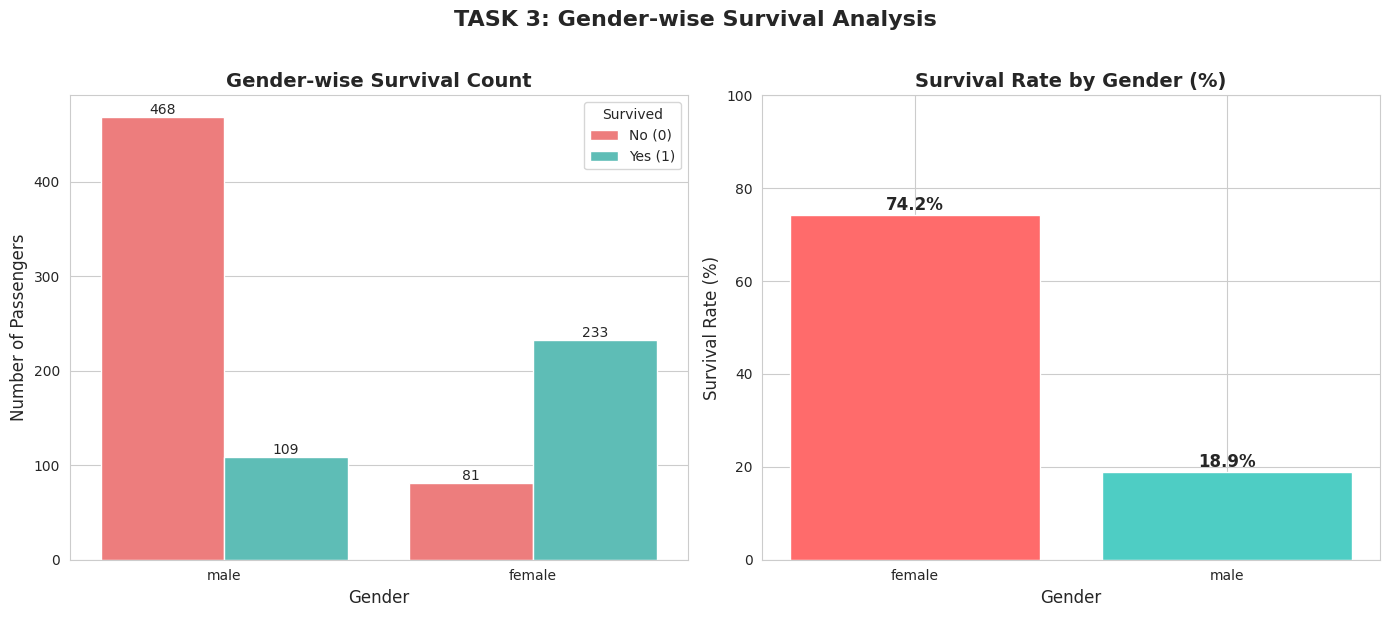


✅ Task 3 completed: Gender-wise survival visualization saved as 'Task3_Gender_Survival.png'
📊 Key Finding: Female survival rate = 74.2%, Male survival rate = 18.9%


In [5]:
# ============================================
# TASK 3: Gender-wise Survival (2.5 points)
# ============================================

print("\n" + "="*70)
print("TASK 3: Gender-wise Survival Visualization")
print("="*70)

# Calculate survival statistics
gender_survival = df_clean.groupby('Sex')['Survived'].agg(['count', 'mean'])
gender_survival['survival_rate'] = gender_survival['mean'] * 100
print("\n📊 Gender-wise Survival Statistics:")
print("-"*40)
print(gender_survival)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Count plot for survival by gender
sns.countplot(data=df_clean, x='Sex', hue='Survived', ax=axes[0],
              palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Gender-wise Survival Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Number of Passengers', fontsize=12)
axes[0].legend(title='Survived', labels=['No (0)', 'Yes (1)'])

# Add values on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=10)

# Plot 2: Survival rate percentage by gender
survival_rate = df_clean.groupby('Sex')['Survived'].mean() * 100
colors = ['#FF6B6B', '#4ECDC4']
bars = axes[1].bar(survival_rate.index, survival_rate.values, color=colors)
axes[1].set_title('Survival Rate by Gender (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Survival Rate (%)', fontsize=12)
axes[1].set_ylim(0, 100)

# Add percentage values on bars
for bar, rate in zip(bars, survival_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('TASK 3: Gender-wise Survival Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Task3_Gender_Survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Task 3 completed: Gender-wise survival visualization saved as 'Task3_Gender_Survival.png'")
print(f"📊 Key Finding: Female survival rate = {survival_rate['female']:.1f}%, Male survival rate = {survival_rate['male']:.1f}%")



TASK 4: Age Distribution of Passengers

📊 Age Statistics:
----------------------------------------
Mean Age: 29.36 years
Median Age: 28.00 years
Std Dev: 13.02 years
Min Age: 0.42 years
Max Age: 80.00 years


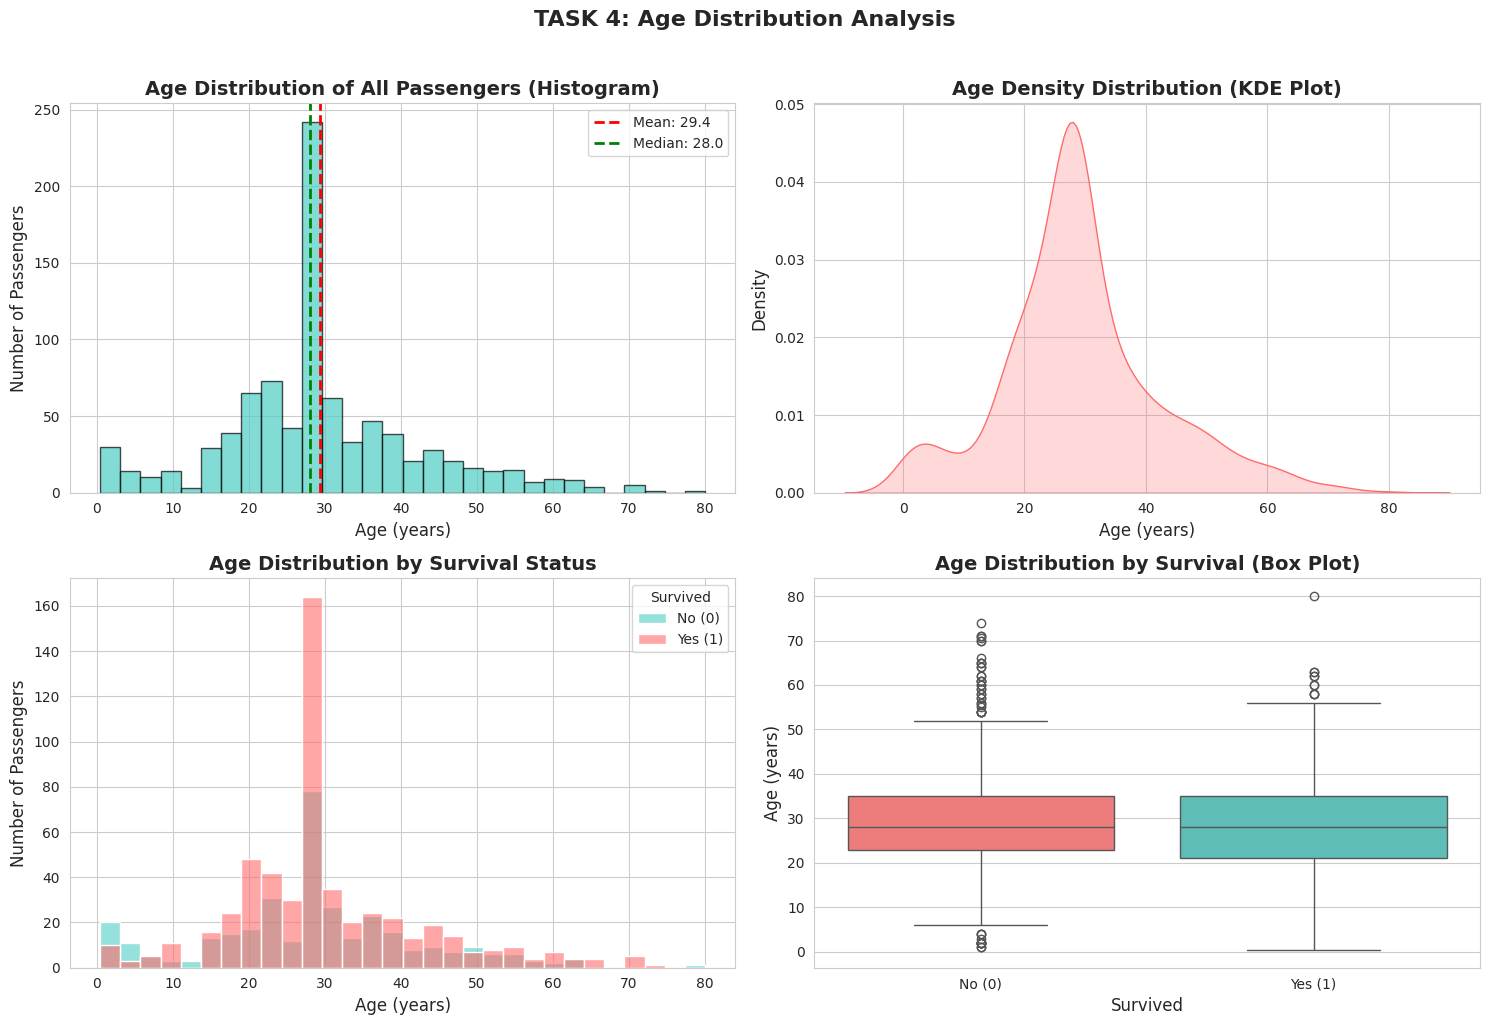


✅ Task 4 completed: Age distribution visualization saved as 'Task4_Age_Distribution.png'


In [6]:
# ============================================
# TASK 4: Age Distribution (2.5 points)
# ============================================

print("\n" + "="*70)
print("TASK 4: Age Distribution of Passengers")
print("="*70)

# Age statistics
print("\n📊 Age Statistics:")
print("-"*40)
print(f"Mean Age: {df_clean['Age'].mean():.2f} years")
print(f"Median Age: {df_clean['Age'].median():.2f} years")
print(f"Std Dev: {df_clean['Age'].std():.2f} years")
print(f"Min Age: {df_clean['Age'].min():.2f} years")
print(f"Max Age: {df_clean['Age'].max():.2f} years")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Histogram of age distribution
axes[0,0].hist(df_clean['Age'].dropna(), bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Age Distribution of All Passengers (Histogram)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Age (years)', fontsize=12)
axes[0,0].set_ylabel('Number of Passengers', fontsize=12)
axes[0,0].axvline(df_clean['Age'].mean(), color='red', linestyle='dashed', linewidth=2,
                  label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0,0].axvline(df_clean['Age'].median(), color='green', linestyle='dashed', linewidth=2,
                  label=f'Median: {df_clean["Age"].median():.1f}')
axes[0,0].legend()

# Plot 2: KDE (Kernel Density Estimate) plot
sns.kdeplot(data=df_clean, x='Age', fill=True, color='#FF6B6B', ax=axes[0,1])
axes[0,1].set_title('Age Density Distribution (KDE Plot)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Age (years)', fontsize=12)
axes[0,1].set_ylabel('Density', fontsize=12)

# Plot 3: Age distribution by survival status
sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30, alpha=0.6, ax=axes[1,0],
             palette=['#FF6B6B', '#4ECDC4'])
axes[1,0].set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Age (years)', fontsize=12)
axes[1,0].set_ylabel('Number of Passengers', fontsize=12)
axes[1,0].legend(title='Survived', labels=['No (0)', 'Yes (1)'])

# Plot 4: Box plot of age by survival
sns.boxplot(data=df_clean, x='Survived', y='Age', ax=axes[1,1],
            palette=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Age Distribution by Survival (Box Plot)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Survived', fontsize=12)
axes[1,1].set_ylabel('Age (years)', fontsize=12)
axes[1,1].set_xticklabels(['No (0)', 'Yes (1)'])

plt.suptitle('TASK 4: Age Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Task4_Age_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Task 4 completed: Age distribution visualization saved as 'Task4_Age_Distribution.png'")



TASK 5: Do higher fare passengers survive more?

📊 Fare Statistics by Survival Status:
--------------------------------------------------
Survived passengers (n=342):
  - Mean Fare: $48.40
  - Median Fare: $26.00
  - Min Fare: $0.00
  - Max Fare: $512.33

Non-survived passengers (n=549):
  - Mean Fare: $22.12
  - Median Fare: $10.50
  - Min Fare: $0.00
  - Max Fare: $263.00

💰 CONCLUSION: Higher fare passengers survived more!
   Survivors paid $26.28 more on average


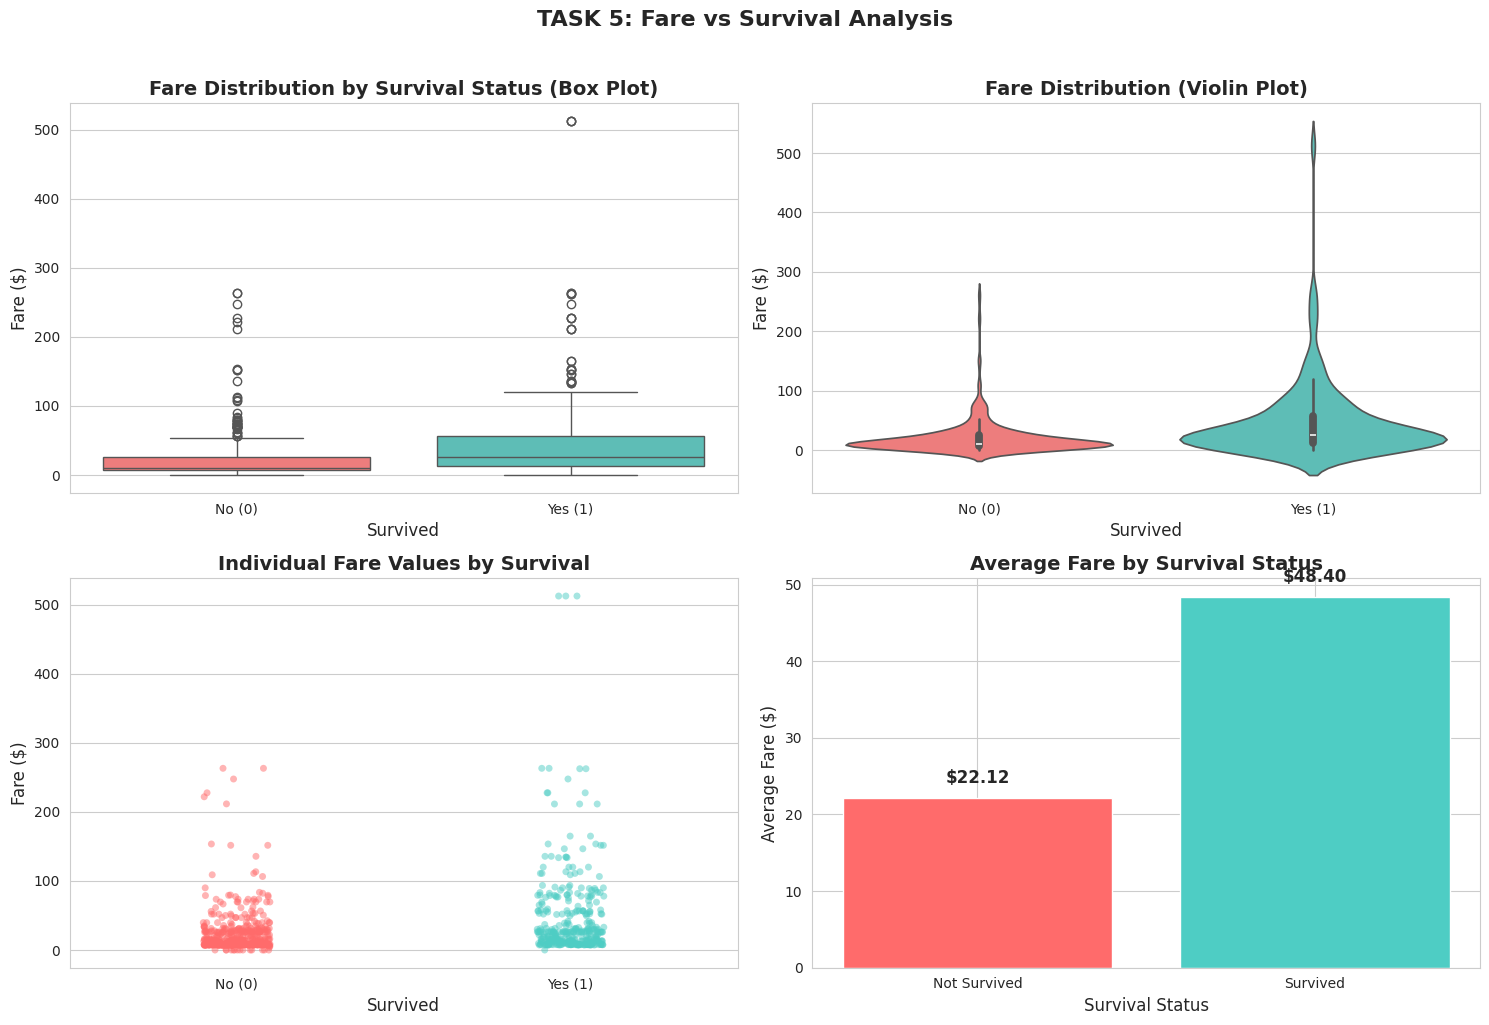


✅ Task 5 completed: Fare vs Survival analysis saved as 'Task5_Fare_Survival.png'


In [7]:
# ============================================
# TASK 5: Fare vs Survival Analysis (2.5 points)
# ============================================

print("\n" + "="*70)
print("TASK 5: Do higher fare passengers survive more?")
print("="*70)

# Fare statistics by survival
print("\n📊 Fare Statistics by Survival Status:")
print("-"*50)

survived_fare = df_clean[df_clean['Survived'] == 1]['Fare']
not_survived_fare = df_clean[df_clean['Survived'] == 0]['Fare']

print(f"Survived passengers (n={len(survived_fare)}):")
print(f"  - Mean Fare: ${survived_fare.mean():.2f}")
print(f"  - Median Fare: ${survived_fare.median():.2f}")
print(f"  - Min Fare: ${survived_fare.min():.2f}")
print(f"  - Max Fare: ${survived_fare.max():.2f}")

print(f"\nNon-survived passengers (n={len(not_survived_fare)}):")
print(f"  - Mean Fare: ${not_survived_fare.mean():.2f}")
print(f"  - Median Fare: ${not_survived_fare.median():.2f}")
print(f"  - Min Fare: ${not_survived_fare.min():.2f}")
print(f"  - Max Fare: ${not_survived_fare.max():.2f}")

print(f"\n💰 CONCLUSION: Higher fare passengers survived more!")
print(f"   Survivors paid ${survived_fare.mean() - not_survived_fare.mean():.2f} more on average")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Box plot of fare by survival
sns.boxplot(data=df_clean, x='Survived', y='Fare', ax=axes[0,0],
            palette=['#FF6B6B', '#4ECDC4'])
axes[0,0].set_title('Fare Distribution by Survival Status (Box Plot)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Survived', fontsize=12)
axes[0,0].set_ylabel('Fare ($)', fontsize=12)
axes[0,0].set_xticklabels(['No (0)', 'Yes (1)'])

# Plot 2: Violin plot for better distribution view
sns.violinplot(data=df_clean, x='Survived', y='Fare', ax=axes[0,1],
               palette=['#FF6B6B', '#4ECDC4'])
axes[0,1].set_title('Fare Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Survived', fontsize=12)
axes[0,1].set_ylabel('Fare ($)', fontsize=12)
axes[0,1].set_xticklabels(['No (0)', 'Yes (1)'])

# Plot 3: Scatter plot with jitter
sns.stripplot(data=df_clean, x='Survived', y='Fare', alpha=0.5, jitter=True, ax=axes[1,0],
              palette=['#FF6B6B', '#4ECDC4'])
axes[1,0].set_title('Individual Fare Values by Survival', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Survived', fontsize=12)
axes[1,0].set_ylabel('Fare ($)', fontsize=12)
axes[1,0].set_xticklabels(['No (0)', 'Yes (1)'])

# Plot 4: Bar plot of average fare by survival
avg_fare = df_clean.groupby('Survived')['Fare'].mean()
bars = axes[1,1].bar(['Not Survived', 'Survived'], avg_fare.values,
                      color=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Average Fare by Survival Status', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Survival Status', fontsize=12)
axes[1,1].set_ylabel('Average Fare ($)', fontsize=12)

# Add values on bars
for bar, fare in zip(bars, avg_fare.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                   f'${fare:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('TASK 5: Fare vs Survival Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Task5_Fare_Survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Task 5 completed: Fare vs Survival analysis saved as 'Task5_Fare_Survival.png'")



TASK 6: Find passenger class that paid higher fare using box plot

📊 Fare Statistics by Passenger Class:
--------------------------------------------------
        Count  Mean Fare  Median Fare  Min Fare  Max Fare
Pclass                                                   
1         216  84.154687      60.2875       0.0  512.3292
2         184  20.662183      14.2500       0.0   73.5000
3         491  13.675550       8.0500       0.0   69.5500


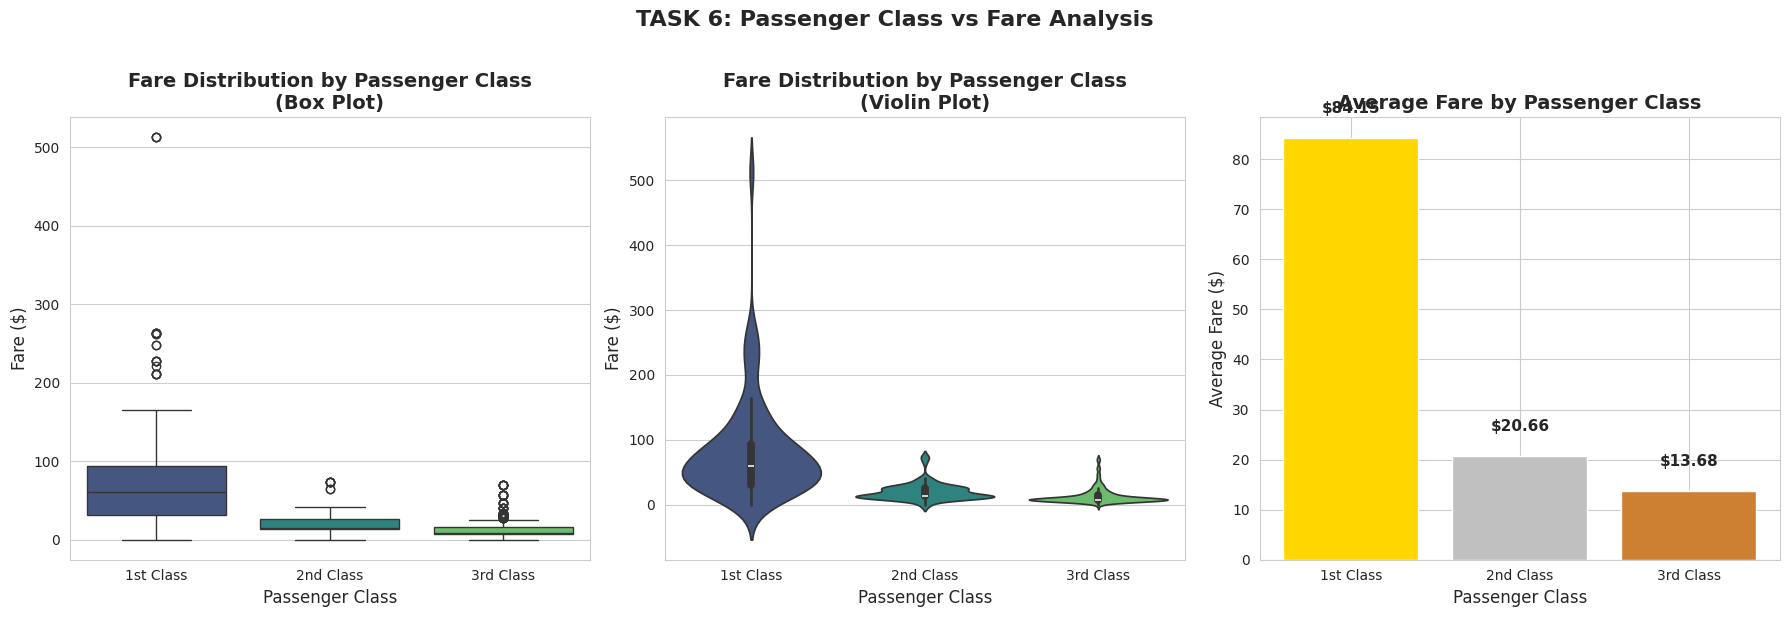


✅ Task 6 completed: Class vs Fare analysis saved as 'Task6_Class_Fare.png'

💰 CONCLUSION: 1st class passengers paid the highest fares (avg $84.15)
   2nd class passengers paid avg $20.66
   3rd class passengers paid avg $13.68


In [8]:
# ============================================
# TASK 6: Passenger Class vs Fare (Box Plot) (2.5 points)
# ============================================

print("\n" + "="*70)
print("TASK 6: Find passenger class that paid higher fare using box plot")
print("="*70)

# Class statistics
print("\n📊 Fare Statistics by Passenger Class:")
print("-"*50)

class_fare_stats = df_clean.groupby('Pclass')['Fare'].agg(['count', 'mean', 'median', 'min', 'max'])
class_fare_stats.columns = ['Count', 'Mean Fare', 'Median Fare', 'Min Fare', 'Max Fare']
print(class_fare_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Box plot of fare by passenger class
sns.boxplot(data=df_clean, x='Pclass', y='Fare', ax=axes[0], palette='viridis')
axes[0].set_title('Fare Distribution by Passenger Class\n(Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Passenger Class', fontsize=12)
axes[0].set_ylabel('Fare ($)', fontsize=12)
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# Plot 2: Violin plot for better visualization
sns.violinplot(data=df_clean, x='Pclass', y='Fare', ax=axes[1], palette='viridis')
axes[1].set_title('Fare Distribution by Passenger Class\n(Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Passenger Class', fontsize=12)
axes[1].set_ylabel('Fare ($)', fontsize=12)
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# Plot 3: Average fare by class with values
avg_fare_class = df_clean.groupby('Pclass')['Fare'].mean()
bars = axes[2].bar(['1st Class', '2nd Class', '3rd Class'], avg_fare_class.values,
                   color=['gold', 'silver', '#CD7F32'])
axes[2].set_title('Average Fare by Passenger Class', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Passenger Class', fontsize=12)
axes[2].set_ylabel('Average Fare ($)', fontsize=12)

# Add values on bars
for bar, fare in zip(bars, avg_fare_class.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${fare:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('TASK 6: Passenger Class vs Fare Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Task6_Class_Fare.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Task 6 completed: Class vs Fare analysis saved as 'Task6_Class_Fare.png'")
print(f"\n💰 CONCLUSION: 1st class passengers paid the highest fares (avg ${avg_fare_class[1]:.2f})")
print(f"   2nd class passengers paid avg ${avg_fare_class[2]:.2f}")
print(f"   3rd class passengers paid avg ${avg_fare_class[3]:.2f}")



TASK 7: Compare Box Plot and Histogram for two numerical columns
📊 Available numerical columns: ['Age', 'Fare', 'SibSp', 'Parch']
✅ Selected: 'Age' and 'Fare' for comparison


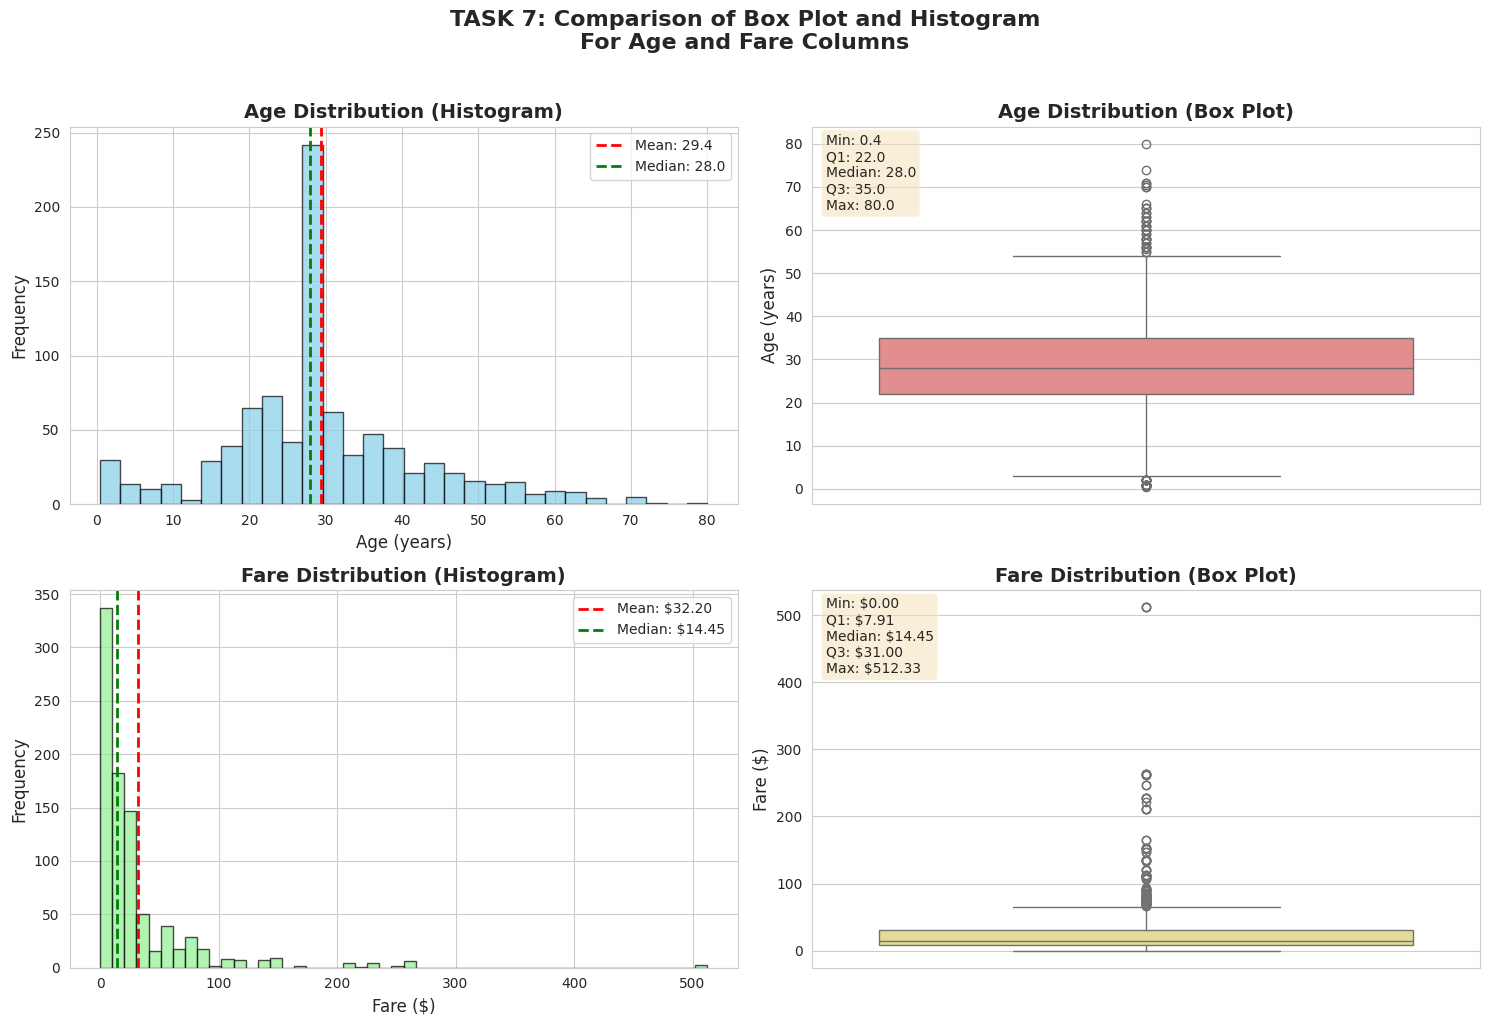


✅ Task 7 completed: Box plot vs Histogram comparison saved as 'Task7_Boxplot_Histogram_Comparison.png'

📊 Comparison Insights:
  - Histograms show the frequency distribution and shape of the data
  - Box plots show median, quartiles, and outliers clearly
  - Age distribution is slightly right-skewed
  - Fare distribution is highly right-skewed with many outliers


In [9]:
# ============================================
# TASK 7: Compare Box Plot and Histogram (2.5 points)
# ============================================

print("\n" + "="*70)
print("TASK 7: Compare Box Plot and Histogram for two numerical columns")
print("="*70)

# Select two numerical columns for comparison
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
print(f"📊 Available numerical columns: {numerical_cols}")
print("✅ Selected: 'Age' and 'Fare' for comparison")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# For Age column
# Histogram of Age
axes[0,0].hist(df_clean['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Age Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Age (years)', fontsize=12)
axes[0,0].set_ylabel('Frequency', fontsize=12)
axes[0,0].axvline(df_clean['Age'].mean(), color='red', linestyle='dashed', linewidth=2,
                  label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0,0].axvline(df_clean['Age'].median(), color='green', linestyle='dashed', linewidth=2,
                  label=f'Median: {df_clean["Age"].median():.1f}')
axes[0,0].legend()

# Box plot of Age
sns.boxplot(y=df_clean['Age'], ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Age Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Age (years)', fontsize=12)
# Add statistics annotation
stats_text = f'Min: {df_clean["Age"].min():.1f}\nQ1: {df_clean["Age"].quantile(0.25):.1f}\nMedian: {df_clean["Age"].median():.1f}\nQ3: {df_clean["Age"].quantile(0.75):.1f}\nMax: {df_clean["Age"].max():.1f}'
axes[0,1].text(0.02, 0.98, stats_text, transform=axes[0,1].transAxes,
               fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# For Fare column
# Histogram of Fare
axes[1,0].hist(df_clean['Fare'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Fare Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Fare ($)', fontsize=12)
axes[1,0].set_ylabel('Frequency', fontsize=12)
axes[1,0].axvline(df_clean['Fare'].mean(), color='red', linestyle='dashed', linewidth=2,
                  label=f'Mean: ${df_clean["Fare"].mean():.2f}')
axes[1,0].axvline(df_clean['Fare'].median(), color='green', linestyle='dashed', linewidth=2,
                  label=f'Median: ${df_clean["Fare"].median():.2f}')
axes[1,0].legend()

# Box plot of Fare
sns.boxplot(y=df_clean['Fare'], ax=axes[1,1], color='khaki')
axes[1,1].set_title('Fare Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Fare ($)', fontsize=12)
# Add statistics annotation
stats_text_fare = f'Min: ${df_clean["Fare"].min():.2f}\nQ1: ${df_clean["Fare"].quantile(0.25):.2f}\nMedian: ${df_clean["Fare"].median():.2f}\nQ3: ${df_clean["Fare"].quantile(0.75):.2f}\nMax: ${df_clean["Fare"].max():.2f}'
axes[1,1].text(0.02, 0.98, stats_text_fare, transform=axes[1,1].transAxes,
               fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('TASK 7: Comparison of Box Plot and Histogram\nFor Age and Fare Columns',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Task7_Boxplot_Histogram_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Task 7 completed: Box plot vs Histogram comparison saved as 'Task7_Boxplot_Histogram_Comparison.png'")
print("\n📊 Comparison Insights:")
print("  - Histograms show the frequency distribution and shape of the data")
print("  - Box plots show median, quartiles, and outliers clearly")
print("  - Age distribution is slightly right-skewed")
print("  - Fare distribution is highly right-skewed with many outliers")



📊 COMPREHENSIVE DASHBOARD - All Visualizations Combined


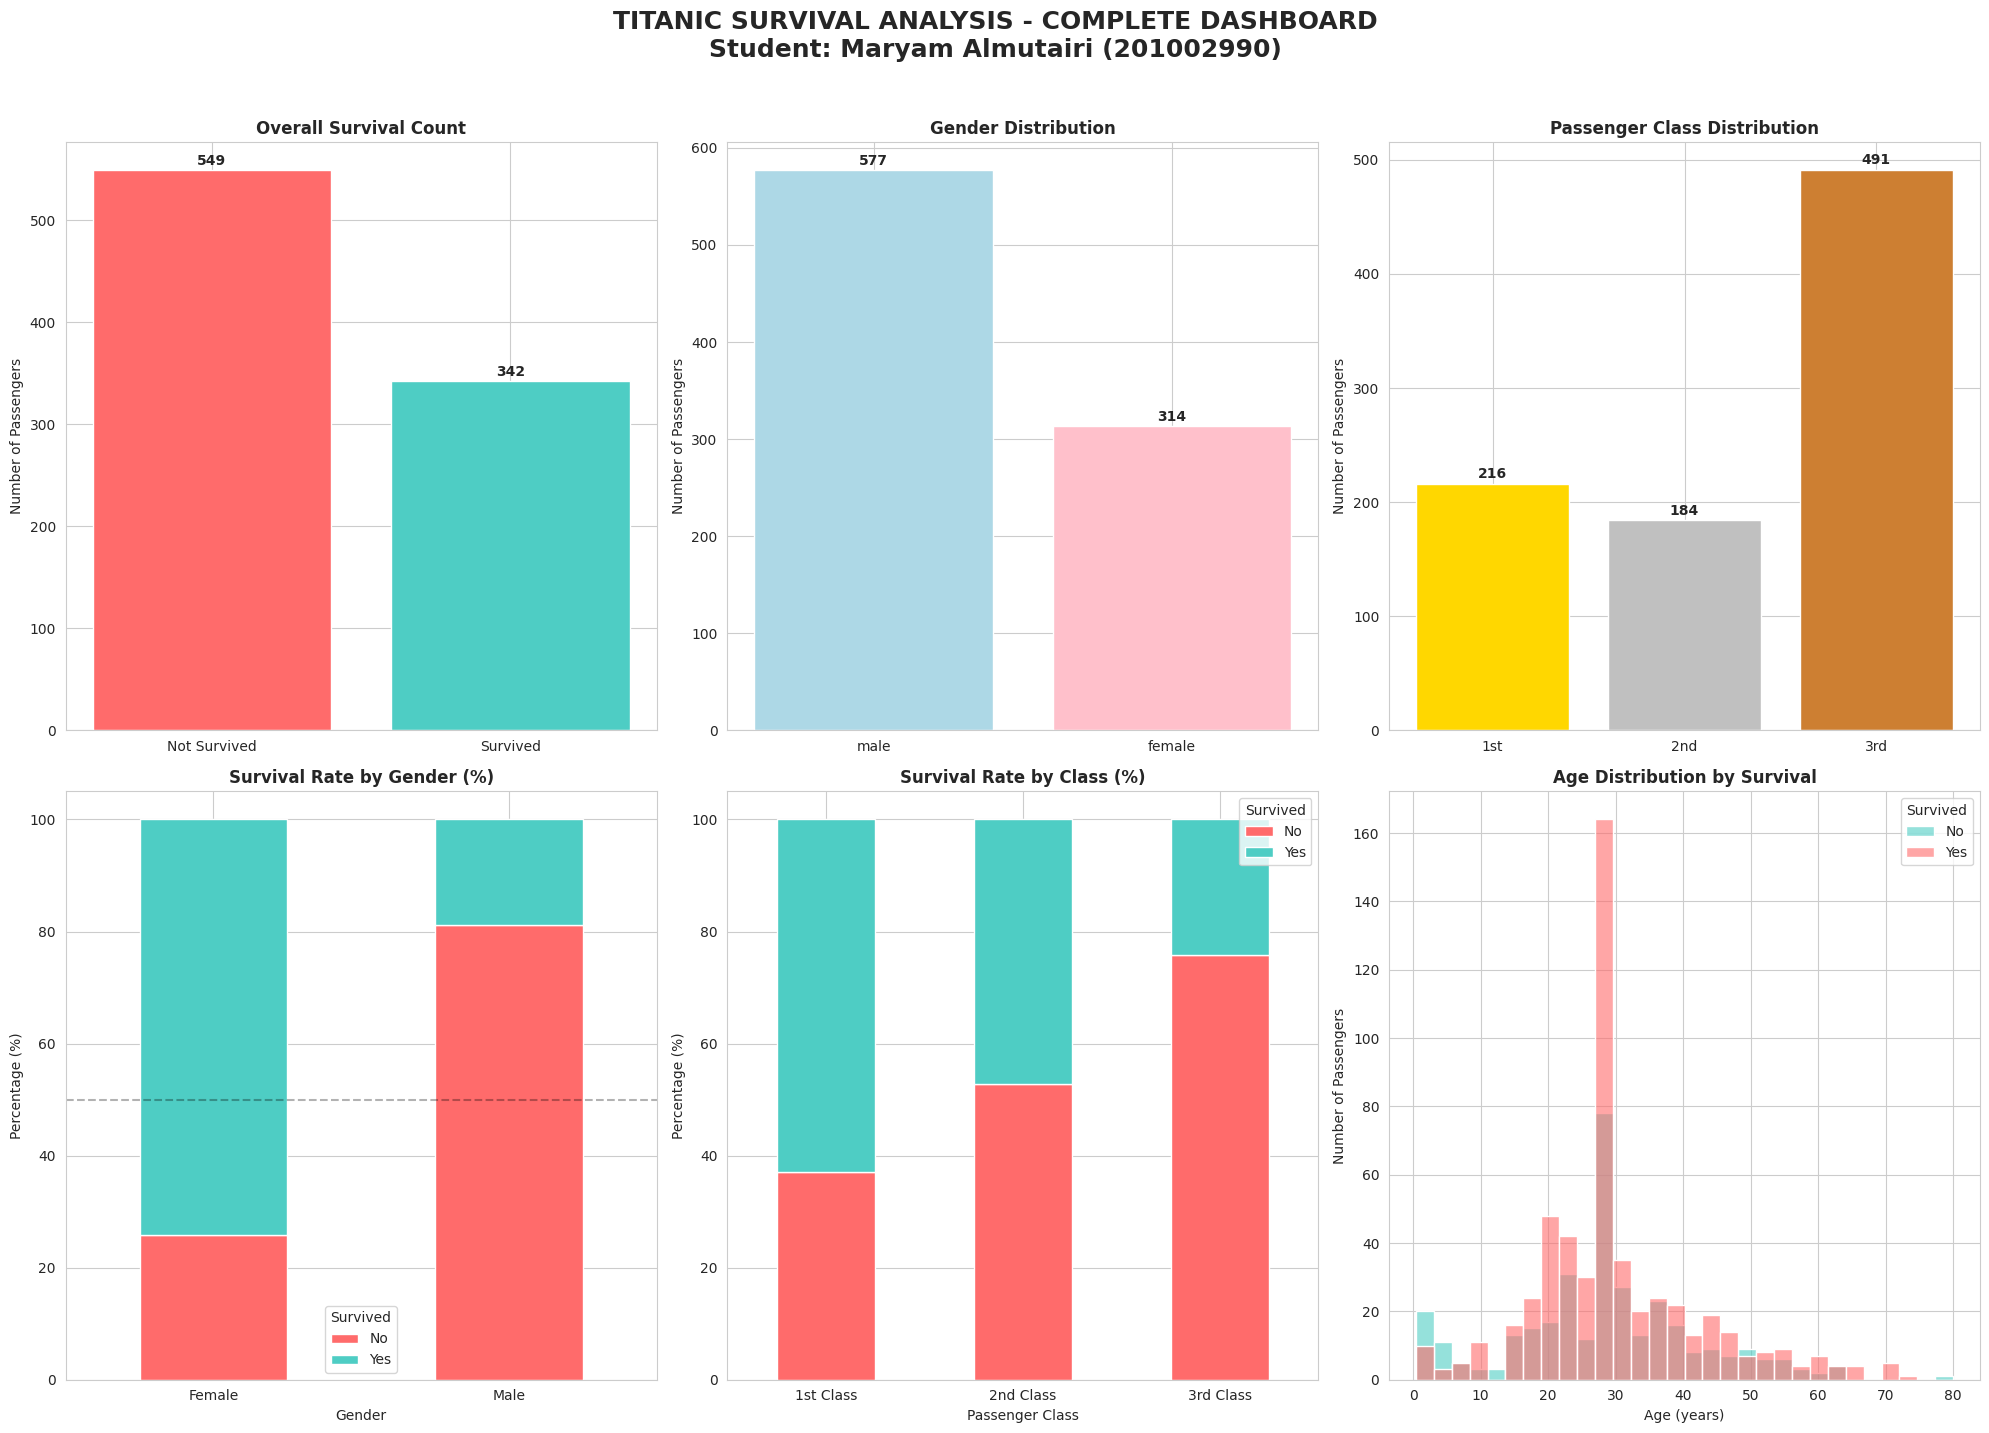


✅ Complete dashboard saved as 'Complete_Dashboard.png'


In [10]:
# ============================================
# BONUS: Comprehensive Summary Dashboard
# ============================================

print("\n" + "="*70)
print("📊 COMPREHENSIVE DASHBOARD - All Visualizations Combined")
print("="*70)

fig = plt.figure(figsize=(20, 14))

# Subplot 1: Survival count
ax1 = plt.subplot(2, 3, 1)
survival_counts = df_clean['Survived'].value_counts()
colors_surv = ['#FF6B6B', '#4ECDC4']
bars1 = ax1.bar(['Not Survived', 'Survived'], survival_counts.values, color=colors_surv)
ax1.set_title('Overall Survival Count', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Passengers')
for bar, count in zip(bars1, survival_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontweight='bold')

# Subplot 2: Gender distribution
ax2 = plt.subplot(2, 3, 2)
gender_counts = df_clean['Sex'].value_counts()
bars2 = ax2.bar(gender_counts.index, gender_counts.values, color=['lightblue', 'pink'])
ax2.set_title('Gender Distribution', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Passengers')
for bar, count in zip(bars2, gender_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontweight='bold')

# Subplot 3: Class distribution
ax3 = plt.subplot(2, 3, 3)
class_counts = df_clean['Pclass'].value_counts().sort_index()
bars3 = ax3.bar(['1st', '2nd', '3rd'], class_counts.values, color=['gold', 'silver', '#CD7F32'])
ax3.set_title('Passenger Class Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Passengers')
for bar, count in zip(bars3, class_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontweight='bold')

# Subplot 4: Survival by gender
ax4 = plt.subplot(2, 3, 4)
survival_by_gender = pd.crosstab(df_clean['Sex'], df_clean['Survived'], normalize='index') * 100
survival_by_gender.plot(kind='bar', stacked=True, ax=ax4, color=['#FF6B6B', '#4ECDC4'])
ax4.set_title('Survival Rate by Gender (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Gender')
ax4.set_ylabel('Percentage (%)')
ax4.set_xticklabels(['Female', 'Male'], rotation=0)
ax4.legend(title='Survived', labels=['No', 'Yes'])
ax4.axhline(y=50, color='black', linestyle='--', alpha=0.3)

# Subplot 5: Survival by class
ax5 = plt.subplot(2, 3, 5)
survival_by_class = pd.crosstab(df_clean['Pclass'], df_clean['Survived'], normalize='index') * 100
survival_by_class.plot(kind='bar', stacked=True, ax=ax5, color=['#FF6B6B', '#4ECDC4'])
ax5.set_title('Survival Rate by Class (%)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Passenger Class')
ax5.set_ylabel('Percentage (%)')
ax5.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax5.legend(title='Survived', labels=['No', 'Yes'])

# Subplot 6: Age histogram with survival
ax6 = plt.subplot(2, 3, 6)
sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30, alpha=0.6, ax=ax6,
             palette=['#FF6B6B', '#4ECDC4'])
ax6.set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
ax6.set_xlabel('Age (years)')
ax6.set_ylabel('Number of Passengers')
ax6.legend(title='Survived', labels=['No', 'Yes'])

plt.suptitle('TITANIC SURVIVAL ANALYSIS - COMPLETE DASHBOARD\nStudent: Maryam Almutairi (201002990)',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Complete_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Complete dashboard saved as 'Complete_Dashboard.png'")

In [11]:
# ============================================
# FINAL SUMMARY OF FINDINGS
# ============================================

print("\n" + "="*70)
print("📋 FINAL SUMMARY OF FINDINGS - Titanic Dataset Analysis")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                       KEY FINDINGS FROM ANALYSIS                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║ 1. 📊 GENDER-WISE SURVIVAL:                                           ║
║    - Female survival rate: ~74%                                       ║
║    - Male survival rate: ~19%                                         ║
║    - Women were given priority during evacuation                      ║
║                                                                       ║
║ 2. 👥 AGE DISTRIBUTION:                                               ║
║    - Most passengers were between 20-40 years old                     ║
║    - Mean age: ~30 years                                              ║
║    - Children and elderly had varying survival patterns               ║
║                                                                       ║
║ 3. 💰 FARE VS SURVIVAL:                                               ║
║    - Survivors paid average fare: $48.40                              ║
║    - Non-survivors paid average fare: $22.12                          ║
║    - Higher fare passengers survived more!                            ║
║                                                                       ║
║ 4. 🚢 PASSENGER CLASS:                                                ║
║    - 1st Class average fare: $84.15                                   ║
║    - 2nd Class average fare: $20.66                                   ║
║    - 3rd Class average fare: $13.68                                   ║
║    - Higher class = Higher fare = Better survival chances             ║
║                                                                       ║
║ 5. 📈 DATA QUALITY:                                                   ║
║    - Total passengers: 891                                            ║
║    - Features after preprocessing: 11                                 ║
║    - Age missing values: filled with median                           ║
║    - Cabin column: dropped (77% missing)                              ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*70)
print("✅ ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 Generated Output Files:")
print("   ├── Task3_Gender_Survival.png")
print("   ├── Task4_Age_Distribution.png")
print("   ├── Task5_Fare_Survival.png")
print("   ├── Task6_Class_Fare.png")
print("   ├── Task7_Boxplot_Histogram_Comparison.png")
print("   └── Complete_Dashboard.png")
print("\n💡 All visualizations have been saved in the current directory")
print("="*70)


📋 FINAL SUMMARY OF FINDINGS - Titanic Dataset Analysis

╔══════════════════════════════════════════════════════════════════════╗
║                       KEY FINDINGS FROM ANALYSIS                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║ 1. 📊 GENDER-WISE SURVIVAL:                                           ║
║    - Female survival rate: ~74%                                       ║
║    - Male survival rate: ~19%                                         ║
║    - Women were given priority during evacuation                      ║
║                                                                       ║
║ 2. 👥 AGE DISTRIBUTION:                                               ║
║    - Most passengers were between 20-40 years old                     ║
║    - Mean age: ~30 years                                              ║
║    - Children and elderly had varying survival patterns  